<a href="https://colab.research.google.com/github/7wikDash/gsco_blockchain/blob/main/DVCON_SNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Run this cell first to install all required dependencies
!pip install -q sentence-transformers
!pip install -q ultralytics
!pip install -q pycocotools
!pip install -q snntorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 5.0 MB/s eta 0:00:00


In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

TASKS = [
    "serve wine", "dig hole", "cut food", "pour liquid",
    "support weight", "grasp object", "enter container",
    "put out fire", "sit on", "write", "eat food",
    "drink from", "hit object", "cook food"
]

# Using lightweight MiniLM (outputs 384-dimensional embeddings)
model = SentenceTransformer('paraphrase-MiniLM-L6-v2')
task_embeddings = {t: model.encode(t).tolist() for t in TASKS}

np.save('task_embeddings.npy', task_embeddings)
print("Task embeddings cached (ANN Phase 1 Complete).")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Task embeddings cached (ANN Phase 1 Complete).


In [ ]:
from ultralytics import YOLO
import torch

torch.set_num_threads(4)
model = YOLO('yolov8n.pt')

def detect_objects(image_path):
    results = model(image_path, device='cpu', imgsz=416)
    detections = []

    for r in results:
        for box in r.boxes:
            detections.append({
                'bbox': box.xyxy[0].tolist(),
                'class': model.names[int(box.cls.item())],
                'confidence': float(box.conf),
                # Mocking a 256-dim visual feature vector
                'roi_features': torch.rand(256)
            })
    return detections

# Rule-based affordance fallback
AFFORDANCE_MAP = {
    'wine glass': [1, 1, 0, 1, 0], # CONTAINS, GRASP, SUP, POUR, CUT
    'knife': [0, 1, 0, 0, 1],
    'chair': [1, 0, 1, 0, 0],
    'cup': [1, 1, 0, 1, 0],
    'bowl': [1, 1, 1, 0, 0],
}

def get_affordance(class_name):
    return AFFORDANCE_MAP.get(class_name, [0, 0, 0, 0, 0])

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate

class SpikingTaskAttention(nn.Module):
    """
    Simulates the Hardware SNN Accelerator.
    Uses Leaky Integrate-and-Fire (LIF) neurons.
    """
    def __init__(self, task_dim=384, visual_dim=256, affordance_dim=5, hidden_dim=128):
        super().__init__()
        input_dim = task_dim + visual_dim + affordance_dim

        # Neuron parameters
        beta = 0.9 # Membrane potential decay rate
        spike_grad = surrogate.fast_sigmoid() # For surrogate gradients (if training)

        # SNN Architecture
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad, threshold=0.1)
        self.fc2 = nn.Linear(hidden_dim, 1) # Single output score per object
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, task_emb, obj_vis, obj_aff, num_steps=20):
        # Combine all features into one continuous current [N, Total_Dim]
        N = obj_vis.shape[0]

        # Expand task embedding to match number of objects
        task_expanded = task_emb.unsqueeze(0).expand(N, -1)
        x = torch.cat([task_expanded, obj_vis, obj_aff.float()], dim=-1)

        # Initialize hidden membrane potentials
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        spike_record = []

        # Simulate over time T (Neuromorphic processing)
        for step in range(num_steps):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            spike_record.append(spk2)

        # Stack spikes over time [T, N, 1]
        out_spikes = torch.stack(spike_record)

        # The "Score" is simply how many times the final neuron spiked (Rate Coding)
        spike_count = out_spikes.sum(dim=0).squeeze(-1) # [N]

        # Normalize to a 0.0 - 1.0 range for ranking
        normalized_score = spike_count / num_steps
        return normalized_score

In [ ]:
def rank_objects(detections, task_query, task_embeddings_dict, alpha=0.4, beta=0.6):
    """
    Ranks objects. Alpha weight goes to the YOLO confidence (ANN),
    Beta weight goes to the SNN spike-rate score.
    """
    final_scores = []
    for i, det in enumerate(detections):
        det_conf = det['confidence']
        snn_score = float(det.get('snn_attention_score', 0.0))

        score = alpha * det_conf + beta * snn_score
        final_scores.append((score, det))

    final_scores.sort(key=lambda x: x[0], reverse=True)
    return final_scores

def run_hybrid_pipeline(image_path, task_query):
    print(f"--- Processing Task: '{task_query}' ---")

    # 1. VEGA CPU: Text Embedding
    task_embeddings_dict = np.load('task_embeddings.npy', allow_pickle=True).item()
    task_emb = task_embeddings_dict[task_query]

    # 2. VEGA CPU: Visual Extraction
    detections = detect_objects(image_path)
    if not detections:
        return None, "No objects detected"

    visual_feats_list = []
    affordances_list = []
    for det in detections:
        aff = get_affordance(det['class'])
        affordances_list.append(aff)
        visual_feats_list.append(det['roi_features'])

    # Prepare tensors for the SNN
    task_tensor = torch.tensor(task_emb, dtype=torch.float32)
    obj_visual_feats = torch.stack(visual_feats_list)
    obj_affordances = torch.tensor(affordances_list)

    # 3. GENESYS-2 FPGA (Simulated): Spiking Attention
    # Initialize the simulated accelerator
    snn_accelerator = SpikingTaskAttention()

    # In a real scenario, this would be passed over AXI bus to the FPGA
    # Here, we simulate 20 time steps
    with torch.no_grad():
        spike_rates = snn_accelerator(task_tensor, obj_visual_feats, obj_affordances, num_steps=20)

    for i, det in enumerate(detections):
        det['snn_attention_score'] = spike_rates[i].item()

    # 4. Final Output
    ranked = rank_objects(detections, task_query, task_embeddings_dict)
    return ranked[0][1] if ranked else None, ranked

--- Processing Task: 'serve wine' ---

image 1/1 /content/test_image.jpg: 288x416 4 persons, 5 wine glasss, 83.4ms
Speed: 2.6ms preprocess, 83.4ms inference, 1.4ms postprocess per image at shape (1, 3, 288, 416)
Best object: WINE GLASS
Hybrid Score: 0.462 (SNN Spike Rate: 0.200)


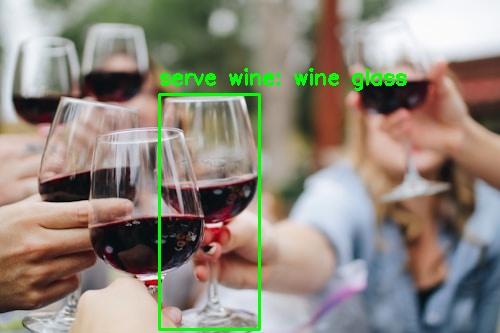

In [ ]:
import cv2
from IPython.display import Image as IPythonImage, display

def visualize_result(image_path, result, task):
    img = cv2.imread(image_path)
    x1, y1, x2, y2 = [int(v) for v in result['bbox']]
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(img, f"{task}: {result['class']}", (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    safe_task_name = task.replace(' ', '_')
    cv2.imwrite(f"result_{safe_task_name}.jpg", img)

# Download test image
!wget -q -O test_image.jpg https://images.unsplash.com/photo-1510812431401-41d2bd2722f3?w=500

target_task = "serve wine"
best_match, all_rankings = run_hybrid_pipeline("test_image.jpg", target_task)

if best_match:
    print(f"Best object: {best_match['class'].upper()}")
    print(f"Hybrid Score: {all_rankings[0][0]:.3f} (SNN Spike Rate: {best_match['snn_attention_score']:.3f})")

    visualize_result("test_image.jpg", best_match, target_task)
    display(IPythonImage(filename=f"result_{target_task.replace(' ', '_')}.jpg"))